In [1]:
# Install required libraries
!pip install scikit-learn nltk rapidfuzz pandas matplotlib seaborn --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 22.3 MB/s eta 0:00:00


In [2]:
import os, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from itertools import combinations
from datetime import datetime
from IPython.display import display, HTML

# NLTK
import nltk
for pkg in ["stopwords", "wordnet", "punkt", "punkt_tab"]:
    nltk.download(pkg, quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# rapidfuzz
from rapidfuzz import fuzz

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [3]:
# ── Tune these values to adjust pipeline behaviour ───────────────────────────
CONFIG = {
    # Ensemble weights  (must sum to 1.0)
    "tfidf_weight"   : 0.50,
    "fuzzy_weight"   : 0.30,
    "jaccard_weight" : 0.20,

    # Severity thresholds (applied to the combined score)
    "thresholds": {
        "high"   : 0.70,   # 🔴 Almost certainly plagiarized
        "medium" : 0.45,   # 🟠 Likely plagiarized
        "low"    : 0.25,   # 🟡 Suspicious overlap
    },

    # TF-IDF
    "ngram_range"  : (1, 2),  # unigrams + bigrams
    "sublinear_tf" : True,    # log(1+tf)  — dampens high-frequency terms

    # Jaccard character n-gram size
    "char_ngram_n" : 3,

    "report_dir"   : "reports",
}

SEVERITY_META = {
    "HIGH"      : ("🔴", "#fdecea", "#e74c3c", "Almost certainly plagiarized"),
    "MEDIUM"    : ("🟠", "#fef3e2", "#e67e22", "Likely plagiarized — review recommended"),
    "SUSPICIOUS": ("🟡", "#fefde2", "#f1c40f", "Suspicious overlap — may need review"),
    "CLEAR"     : ("🟢", "#eafaf1", "#27ae60", "Acceptable similarity"),
}

os.makedirs(CONFIG["report_dir"], exist_ok=True)
print("✅ Config ready | Thresholds:", CONFIG["thresholds"])

✅ Config ready | Thresholds: {'high': 0.7, 'medium': 0.45, 'low': 0.25}


In [5]:
STOP_WORDS = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def clean_text(text: str) -> str:
    """Remove noise: URLs, HTML tags, punctuation, digits, extra whitespace."""
    text = re.sub(r"http\S+|www\S+", " ", text)   # URLs
    text = re.sub(r"<[^>]+>",        " ", text)   # HTML tags
    text = re.sub(r"[^\w\s]",        " ", text)   # punctuation
    text = re.sub(r"\d+",            " ", text)   # digits
    return re.sub(r"\s+",            " ", text).strip()


def normalize(text: str) -> str:
    return clean_text(text.lower())


def preprocess(text: str, return_tokens: bool = False):
    """
    Full normalization pipeline:
      clean → lowercase → tokenize → remove stopwords → lemmatize

    Parameters
    ----------
    text          : raw document text
    return_tokens : if True, return list of tokens; else return joined string
    """
    tokens = word_tokenize(normalize(text))
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 1]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return tokens if return_tokens else " ".join(tokens)


# ── Quick demo ─────────────────────────────────────────────────────────────────
sample = "Machine Learning algorithms Improve automatically through Experience and DATA!"
print("Raw    :", sample)
print("Tokens :", preprocess(sample, return_tokens=True))
print("Joined :", preprocess(sample))

Raw    : Machine Learning algorithms Improve automatically through Experience and DATA!
Tokens : ['machine', 'learning', 'algorithm', 'improve', 'automatically', 'experience', 'data']
Joined : machine learning algorithm improve automatically experience data


In [6]:
def get_char_ngrams(text: str, n: int = 3) -> set:
    """Character n-grams from space-stripped, normalized text."""
    t = re.sub(r"\s", "", normalize(text))
    return set(t[i:i+n] for i in range(len(t) - n + 1)) if len(t) >= n else set()


def get_word_ngrams(tokens: list, n: int = 2) -> set:
    """Word n-gram tuples from a token list."""
    if len(tokens) < n:
        return set()
    return set(tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1))


def jaccard_similarity(set_a: set, set_b: set) -> float:
    """Jaccard index: |A ∩ B| / |A ∪ B|"""
    if not set_a or not set_b:
        return 0.0
    return len(set_a & set_b) / len(set_a | set_b)


# ── Demo ────────────────────────────────────────────────────────────────────────
demo_text = "machine learning algorithms"
tok = preprocess(demo_text, return_tokens=True)
print("Char trigrams (first 8):", sorted(get_char_ngrams(demo_text))[:8])
print("Word bigrams            :", get_word_ngrams(tok, n=2))

Char trigrams (first 8): ['ach', 'alg', 'arn', 'chi', 'ear', 'ele', 'gal', 'gor']
Word bigrams            : {('learning', 'algorithm'), ('machine', 'learning')}


In [7]:
# ── Method 1: TF-IDF Cosine Similarity (batch) ────────────────────────────────

def build_tfidf_matrix(processed_docs: list) -> np.ndarray:
    """
    Fit TF-IDF vectorizer on the full corpus, return (n x n) cosine similarity matrix.
    ngram_range=(1,2)  captures unigrams AND bigrams.
    sublinear_tf=True  applies log(1+tf) to dampen high-frequency terms.
    """
    vectorizer = TfidfVectorizer(
        ngram_range  = CONFIG["ngram_range"],
        sublinear_tf = CONFIG["sublinear_tf"],
        min_df       = 1,
    )
    tfidf_matrix = vectorizer.fit_transform(processed_docs)
    return cosine_similarity(tfidf_matrix)   # shape: (n_docs, n_docs)


# ── Method 2: rapidfuzz Ensemble ──────────────────────────────────────────────

def compute_fuzzy_similarity(text_a: str, text_b: str) -> float:
    """
    Weighted ensemble of three rapidfuzz metrics (all normalized to [0, 1]).

    ratio           (0.25) – character edit distance
    token_sort_ratio(0.50) – order-independent token matching (best for paraphrase)
    partial_ratio   (0.25) – best sub-string alignment (best for partial copy)
    """
    r1 = fuzz.ratio(text_a, text_b)            / 100
    r2 = fuzz.token_sort_ratio(text_a, text_b) / 100
    r3 = fuzz.partial_ratio(text_a, text_b)    / 100
    return 0.25 * r1 + 0.50 * r2 + 0.25 * r3


# ── Method 3: Jaccard N-gram Similarity ───────────────────────────────────────

def compute_jaccard_similarity(text_a: str, text_b: str) -> float:
    """
    Combined Jaccard similarity:
      40%  character trigrams  (catches spelling variants, close paraphrase)
      60%  word bigrams        (catches phrase-level structural similarity)
    """
    char_j = jaccard_similarity(
        get_char_ngrams(text_a, CONFIG["char_ngram_n"]),
        get_char_ngrams(text_b, CONFIG["char_ngram_n"]),
    )
    bigram_j = jaccard_similarity(
        get_word_ngrams(preprocess(text_a, return_tokens=True), n=2),
        get_word_ngrams(preprocess(text_b, return_tokens=True), n=2),
    )
    return 0.40 * char_j + 0.60 * bigram_j


# ── Weighted Ensemble ──────────────────────────────────────────────────────────

def combined_score(tfidf: float, fuzzy: float, jaccard: float) -> float:
    """Weighted ensemble: TF-IDF(0.5) + Fuzzy(0.3) + Jaccard(0.2)."""
    return (CONFIG["tfidf_weight"]   * tfidf   +
            CONFIG["fuzzy_weight"]   * fuzzy   +
            CONFIG["jaccard_weight"] * jaccard)


print("✅ Similarity functions ready")

✅ Similarity functions ready


In [8]:
def flag_severity(score: float) -> str:
    """Map a combined score to a severity label using CONFIG thresholds."""
    t = CONFIG["thresholds"]
    if   score >= t["high"]  : return "HIGH"
    elif score >= t["medium"]: return "MEDIUM"
    elif score >= t["low"]   : return "SUSPICIOUS"
    else                     : return "CLEAR"


# ── Threshold legend ───────────────────────────────────────────────────────────
print(f"{'Range':>12}   Verdict")
print("-" * 52)
ranges = [
    (CONFIG["thresholds"]["high"],   1.00,                            "HIGH"),
    (CONFIG["thresholds"]["medium"], CONFIG["thresholds"]["high"],    "MEDIUM"),
    (CONFIG["thresholds"]["low"],    CONFIG["thresholds"]["medium"],  "SUSPICIOUS"),
    (0.00,                           CONFIG["thresholds"]["low"],     "CLEAR"),
]
for lo, hi, label in ranges:
    icon, _, _, desc = SEVERITY_META[label]
    print(f"  {lo:.2f} – {hi:.2f}   {icon} {label:<12}  {desc}")

       Range   Verdict
----------------------------------------------------
  0.70 – 1.00   🔴 HIGH          Almost certainly plagiarized
  0.45 – 0.70   🟠 MEDIUM        Likely plagiarized — review recommended
  0.25 – 0.45   🟡 SUSPICIOUS    Suspicious overlap — may need review
  0.00 – 0.25   🟢 CLEAR         Acceptable similarity


In [9]:
class PlagiarismChecker:
    """
    End-to-end plagiarism detection pipeline.

    Usage
    -----
    checker = PlagiarismChecker({"file1.txt": "text...", "file2.txt": "text..."})
    checker.check_all()       # run all pairwise comparisons
    checker.summary()         # print ASCII summary
    checker.get_dataframe()   # pandas DataFrame of results
    """

    def __init__(self, documents: dict):
        self.documents       = documents
        self.filenames       = list(documents.keys())
        self.raw_texts       = list(documents.values())
        self.processed_texts = [preprocess(t) for t in self.raw_texts]
        self._tfidf_sim      = None
        self.results         = []

    # ──────────────────────────────────────────────────────────────────────────

    def check_all(self) -> list:
        """Run all pairwise comparisons. Results sorted by combined score ↓."""
        self._tfidf_sim = build_tfidf_matrix(self.processed_texts)
        self.results    = []

        for i, j in combinations(range(len(self.filenames)), 2):
            tfidf_s   = float(self._tfidf_sim[i, j])
            fuzzy_s   = compute_fuzzy_similarity(self.raw_texts[i], self.raw_texts[j])
            jaccard_s = compute_jaccard_similarity(self.raw_texts[i], self.raw_texts[j])
            final     = combined_score(tfidf_s, fuzzy_s, jaccard_s)

            self.results.append({
                "doc_a"         : self.filenames[i],
                "doc_b"         : self.filenames[j],
                "tfidf_score"   : round(tfidf_s,   4),
                "fuzzy_score"   : round(fuzzy_s,   4),
                "jaccard_score" : round(jaccard_s, 4),
                "combined_score": round(final,     4),
                "severity"      : flag_severity(final),
            })

        self.results.sort(key=lambda x: x["combined_score"], reverse=True)
        return self.results

    # ──────────────────────────────────────────────────────────────────────────

    def get_dataframe(self) -> pd.DataFrame:
        """Return results as a pandas DataFrame (runs check_all if not yet done)."""
        if not self.results:
            self.check_all()
        return pd.DataFrame(self.results)

    def summary(self):
        """Print ASCII summary table."""
        df   = self.get_dataframe()
        cnts = df["severity"].value_counts()
        print("\n" + "═" * 58)
        print("           PLAGIARISM CHECK SUMMARY")
        print("═" * 58)
        print(f"  Documents checked  : {len(self.filenames)}")
        print(f"  Pairs compared     : {len(self.results)}")
        print("─" * 58)
        for sev in ["HIGH", "MEDIUM", "SUSPICIOUS", "CLEAR"]:
            n    = cnts.get(sev, 0)
            icon = SEVERITY_META[sev][0]
            bar  = "█" * (n * 4)
            print(f"  {icon} {sev:<12}: {n:>3}   {bar}")
        print("═" * 58 + "\n")


print("✅ PlagiarismChecker class ready")

✅ PlagiarismChecker class ready


In [10]:
def plot_similarity_heatmap(checker: PlagiarismChecker, save: bool = True):
    """Colour-coded heatmap of combined similarity scores."""
    n     = len(checker.filenames)
    mat   = np.zeros((n, n))
    names = [Path(f).stem for f in checker.filenames]

    for r in checker.results:
        i = checker.filenames.index(r["doc_a"])
        j = checker.filenames.index(r["doc_b"])
        mat[i, j] = mat[j, i] = r["combined_score"]
    np.fill_diagonal(mat, 1.0)

    fig, ax = plt.subplots(figsize=(max(6, n), max(5, n - 1)))
    sns.heatmap(
        mat, annot=True, fmt=".2f",
        xticklabels=names, yticklabels=names,
        cmap="YlOrRd", vmin=0, vmax=1,
        linewidths=0.6, linecolor="white", ax=ax,
        annot_kws={"size": 11, "weight": "bold"},
    )
    ax.set_title("Pairwise Similarity Heatmap  (Combined Score)", fontsize=14, pad=14)
    plt.tight_layout()
    if save:
        p = f"{CONFIG['report_dir']}/similarity_heatmap.png"
        plt.savefig(p, dpi=150, bbox_inches="tight")
        print(f"Saved → {p}")
    plt.show()


def plot_score_breakdown(checker: PlagiarismChecker, save: bool = True):
    """Grouped bar chart: TF-IDF vs Fuzzy vs Jaccard per pair + threshold lines."""
    df = checker.get_dataframe().copy()
    df["pair"] = (df["doc_a"].apply(lambda x: Path(x).stem) + "\nvs\n"
                + df["doc_b"].apply(lambda x: Path(x).stem))

    x, w = np.arange(len(df)), 0.25
    fig, ax = plt.subplots(figsize=(max(9, len(df) * 2.4), 5))

    ax.bar(x - w, df["tfidf_score"],   w, label="TF-IDF Cosine",  color="#3498db", alpha=0.85)
    ax.bar(x,     df["fuzzy_score"],   w, label="Fuzzy Ensemble",  color="#e67e22", alpha=0.85)
    ax.bar(x + w, df["jaccard_score"], w, label="Jaccard N-gram",  color="#2ecc71", alpha=0.85)

    tcol = {"high": "#e74c3c", "medium": "#e67e22", "low": "#f1c40f"}
    for level, val in CONFIG["thresholds"].items():
        ax.axhline(val, linestyle="--", color=tcol[level],
                   alpha=0.75, linewidth=1.5,
                   label=f"{level.capitalize()} threshold ({val})")

    ax.set_xticks(x)
    ax.set_xticklabels(df["pair"], ha="center", fontsize=8)
    ax.set_ylabel("Similarity Score", fontsize=11)
    ax.set_title("Score Breakdown by Method per Document Pair", fontsize=13)
    ax.legend(fontsize=8, ncol=3, loc="upper right")
    ax.set_ylim(0, 1.18)
    plt.tight_layout()
    if save:
        p = f"{CONFIG['report_dir']}/score_breakdown.png"
        plt.savefig(p, dpi=150, bbox_inches="tight")
        print(f"Saved → {p}")
    plt.show()


def plot_severity_pie(checker: PlagiarismChecker, save: bool = True):
    """Pie chart of severity distribution across all document pairs."""
    df    = checker.get_dataframe()
    cnts  = df["severity"].value_counts().reindex(
        ["HIGH", "MEDIUM", "SUSPICIOUS", "CLEAR"], fill_value=0
    )
    colors = [SEVERITY_META[k][2] for k in cnts.index]
    labels = [f"{k}\n({v} pairs)" for k, v in cnts.items()]

    fig, ax = plt.subplots(figsize=(5, 5))
    wedges, texts, autotexts = ax.pie(
        cnts, labels=labels, colors=colors,
        autopct=lambda p: f"{p:.0f}%" if p > 0 else "",
        startangle=140, pctdistance=0.72,
        wedgeprops=dict(edgecolor="white", linewidth=2.5),
    )
    for t in autotexts:
        t.set_fontsize(11)
        t.set_fontweight("bold")
    ax.set_title("Severity Distribution", fontsize=13, pad=14)
    plt.tight_layout()
    if save:
        p = f"{CONFIG['report_dir']}/severity_pie.png"
        plt.savefig(p, dpi=150, bbox_inches="tight")
        print(f"Saved → {p}")
    plt.show()


print("✅ Visualization functions ready")

✅ Visualization functions ready


In [11]:
def generate_html_report(checker: PlagiarismChecker,
                          output_path: str = None) -> str:
    """Generate a fully styled HTML plagiarism report."""
    if output_path is None:
        output_path = f"{CONFIG['report_dir']}/plagiarism_report.html"

    df    = checker.get_dataframe()
    ts    = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    cnts  = df["severity"].value_counts()

    # ── Summary cards ─────────────────────────────────────────────────────────
    card_html = ""
    for sev in ["HIGH", "MEDIUM", "SUSPICIOUS", "CLEAR"]:
        icon, bg, border, _ = SEVERITY_META[sev]
        n = cnts.get(sev, 0)
        card_html += (
            '<div class="card" style="background:' + bg + ';border:2px solid ' + border + ';">'
            '<div class="num" style="color:' + border + ';">' + str(n) + '</div>'
            '<div class="label" style="color:' + border + ';">' + icon + ' ' + sev + '</div>'
            '</div>'
        )

    # ── Results table rows ────────────────────────────────────────────────────
    rows_html = ""
    for _, row in df.iterrows():
        icon, bg, border, _ = SEVERITY_META[row["severity"]]
        rows_html += (
            '<tr style="background:' + bg + ';border-left:5px solid ' + border + ';">'
            '<td>' + icon + ' <strong>' + row["doc_a"] + '</strong></td>'
            '<td><strong>' + row["doc_b"] + '</strong></td>'
            '<td class="num">' + f"{row['tfidf_score']:.4f}" + '</td>'
            '<td class="num">' + f"{row['fuzzy_score']:.4f}" + '</td>'
            '<td class="num">' + f"{row['jaccard_score']:.4f}" + '</td>'
            '<td class="num"><strong>' + f"{row['combined_score']:.4f}" + '</strong></td>'
            '<td style="color:' + border + ';font-weight:700;">' + row["severity"] + '</td>'
            '</tr>'
        )

    # ── Build full HTML (no f-string — avoids triple-quote nesting issues) ────
    css = (
        "body{font-family:'Segoe UI',Arial,sans-serif;max-width:1100px;margin:0 auto;"
        "padding:28px;color:#222;}"
        "h1{color:#2c3e50;border-bottom:3px solid #3498db;padding-bottom:8px;}"
        "h2{color:#34495e;margin-top:30px;}"
        ".meta{color:#888;font-size:13px;margin-bottom:22px;}"
        ".cards{display:flex;gap:14px;flex-wrap:wrap;margin-bottom:26px;}"
        ".card{flex:1;min-width:120px;padding:14px 18px;border-radius:10px;text-align:center;}"
        ".card .num{font-size:30px;font-weight:bold;}"
        ".card .label{font-size:11px;text-transform:uppercase;letter-spacing:1px;margin-top:4px;}"
        "table{width:100%;border-collapse:collapse;font-size:14px;}"
        "th{background:#2c3e50;color:#fff;padding:10px 12px;text-align:left;}"
        "td{padding:9px 12px;border-bottom:1px solid #eee;}"
        "td.num{text-align:right;font-family:monospace;}"
        "tr:hover td{filter:brightness(0.96);}"
        ".footer{margin-top:20px;font-size:11px;color:#aaa;border-top:1px solid #eee;padding-top:10px;}"
    )

    threshold_rows = (
        '<tr style="background:#fdecea;border-left:5px solid #e74c3c;">'
        '<td>🔴 HIGH</td><td>&ge; 0.70</td><td>Almost certainly plagiarized</td></tr>'
        '<tr style="background:#fef3e2;border-left:5px solid #e67e22;">'
        '<td>🟠 MEDIUM</td><td>0.45 &ndash; 0.69</td><td>Likely plagiarized &mdash; review recommended</td></tr>'
        '<tr style="background:#fefde2;border-left:5px solid #f1c40f;">'
        '<td>🟡 SUSPICIOUS</td><td>0.25 &ndash; 0.44</td><td>Suspicious overlap &mdash; may need review</td></tr>'
        '<tr style="background:#eafaf1;border-left:5px solid #27ae60;">'
        '<td>🟢 CLEAR</td><td>&lt; 0.25</td><td>Acceptable similarity</td></tr>'
    )

    html = "\n".join([
        "<!DOCTYPE html>",
        '<html lang="en"><head><meta charset="UTF-8">',
        "<title>Plagiarism Detection Report</title>",
        "<style>" + css + "</style></head><body>",
        "<h1>📄 Plagiarism Detection Report</h1>",
        '<p class="meta">Generated: ' + ts + "&nbsp;|&nbsp;Documents: "
            + str(len(checker.filenames)) + "&nbsp;|&nbsp;Pairs compared: " + str(len(df)) + "</p>",
        '<div class="cards">' + card_html + "</div>",
        "<h2>Pairwise Results</h2>",
        "<table>",
        "  <tr><th>Document A</th><th>Document B</th>"
        "<th>TF-IDF</th><th>Fuzzy</th><th>Jaccard</th>"
        "<th>Combined</th><th>Verdict</th></tr>",
        rows_html,
        "</table>",
        "<h2>Threshold Reference</h2>",
        "<table>",
        "  <tr><th>Verdict</th><th>Score Range</th><th>Meaning</th></tr>",
        threshold_rows,
        "</table>",
        '<p class="footer">Pipeline: TF-IDF cosine (w=0.5) + '
        "rapidfuzz ensemble (w=0.3) + Jaccard n-gram (w=0.2)</p>",
        "</body></html>",
    ])

    with open(output_path, "w", encoding="utf-8") as f:
        f.write(html)
    print(f"✅ HTML report → {output_path}")
    return output_path


def generate_csv_report(checker: PlagiarismChecker,
                         output_path: str = None) -> pd.DataFrame:
    """Export all pairwise results to CSV."""
    if output_path is None:
        output_path = f"{CONFIG['report_dir']}/results.csv"
    df = checker.get_dataframe()
    df.to_csv(output_path, index=False)
    print(f"✅ CSV report   → {output_path}")
    return df


print("✅ Report generators ready")

✅ Report generators ready


In [12]:
SAMPLE_DOCS = {
    "A_original.txt": (
        "Machine learning is a subset of artificial intelligence that gives computers "
        "the ability to learn from data without being explicitly programmed. "
        "It focuses on developing algorithms that improve automatically through "
        "experience and data, building models that generalize to unseen examples."
    ),

    "B_direct_copy.txt": (
        "Machine learning is a subset of artificial intelligence that gives computers "
        "the ability to learn from data without being explicitly programmed. "
        "It focuses on developing algorithms that improve automatically through "
        "experience and data, building models that generalize to unseen examples."
    ),

    "C_paraphrased.txt": (
        "Machine learning is an artificial intelligence technique that enables "
        "computers to automatically learn from data without explicit programming. "
        "Algorithms improve through experience and data, developing models "
        "that generalize to unseen examples and new inputs."
    ),

    "D_related_topic.txt": (
        "Artificial intelligence systems use machine learning algorithms trained "
        "on large datasets to identify patterns and improve their performance. "
        "Deep learning models can learn hierarchical representations from data, "
        "achieving strong generalization on tasks they have not seen before."
    ),

    "E_unrelated.txt": (
        "The Indian Premier League is a professional Twenty20 cricket tournament "
        "held every year in India. Franchise teams from different cities compete "
        "over several weeks in a double round-robin format followed by playoffs. "
        "Millions of fans watch the matches live and on broadcast television."
    ),
}

# ── Preprocessing preview ──────────────────────────────────────────────────────
print("Preprocessed tokens per document (first 8):")
for name, text in SAMPLE_DOCS.items():
    tokens = preprocess(text, return_tokens=True)
    print(f"  {name:<22}: {tokens[:8]} ...")

Preprocessed tokens per document (first 8):
  A_original.txt        : ['machine', 'learning', 'subset', 'artificial', 'intelligence', 'give', 'computer', 'ability'] ...
  B_direct_copy.txt     : ['machine', 'learning', 'subset', 'artificial', 'intelligence', 'give', 'computer', 'ability'] ...
  C_paraphrased.txt     : ['machine', 'learning', 'artificial', 'intelligence', 'technique', 'enables', 'computer', 'automatically'] ...
  D_related_topic.txt   : ['artificial', 'intelligence', 'system', 'use', 'machine', 'learning', 'algorithm', 'trained'] ...
  E_unrelated.txt       : ['indian', 'premier', 'league', 'professional', 'twenty', 'cricket', 'tournament', 'held'] ...


In [13]:
# ── Run the full pipeline ──────────────────────────────────────────────────────
checker = PlagiarismChecker(SAMPLE_DOCS)
results = checker.check_all()
checker.summary()


══════════════════════════════════════════════════════════
           PLAGIARISM CHECK SUMMARY
══════════════════════════════════════════════════════════
  Documents checked  : 5
  Pairs compared     : 10
──────────────────────────────────────────────────────────
  🔴 HIGH        :   1   ████
  🟠 MEDIUM      :   2   ████████
  🟡 SUSPICIOUS  :   0   
  🟢 CLEAR       :   7   ████████████████████████████
══════════════════════════════════════════════════════════



In [14]:
# ── Styled results DataFrame ───────────────────────────────────────────────────
df = checker.get_dataframe()

score_cols = ["tfidf_score", "fuzzy_score", "jaccard_score", "combined_score"]

styled = (
    df.style
    .background_gradient(subset=["combined_score"], cmap="YlOrRd", vmin=0, vmax=1)
    .background_gradient(subset=["tfidf_score", "fuzzy_score", "jaccard_score"],
                         cmap="Blues", vmin=0, vmax=1)
    .format({c: "{:.4f}" for c in score_cols})
    .set_caption("Pairwise plagiarism results — sorted by combined score ↓")
)
display(styled)

,doc_a,doc_b,tfidf_score,fuzzy_score,jaccard_score,combined_score,severity
0,A_original.txt,B_direct_copy.txt,1.0000,1.0000,1.0000,1.0000,HIGH
1,A_original.txt,C_paraphrased.txt,0.3885,0.7755,0.3806,0.5030,MEDIUM
2,B_direct_copy.txt,C_paraphrased.txt,0.3885,0.7755,0.3806,0.5030,MEDIUM
3,A_original.txt,D_related_topic.txt,0.1195,0.5056,0.1180,0.2350,CLEAR
4,B_direct_copy.txt,D_related_topic.txt,0.1195,0.5056,0.1180,0.2350,CLEAR
5,C_paraphrased.txt,D_related_topic.txt,0.1079,0.4840,0.1230,0.2238,CLEAR
6,D_related_topic.txt,E_unrelated.txt,0.0000,0.4289,0.0338,0.1354,CLEAR
7,A_original.txt,E_unrelated.txt,0.0000,0.4215,0.0351,0.1335,CLEAR
8,B_direct_copy.txt,E_unrelated.txt,0.0000,0.4215,0.0351,0.1335,CLEAR
9,C_paraphrased.txt,E_unrelated.txt,0.0000,0.4173,0.0325,0.1317,CLEAR


Saved → reports/similarity_heatmap.png


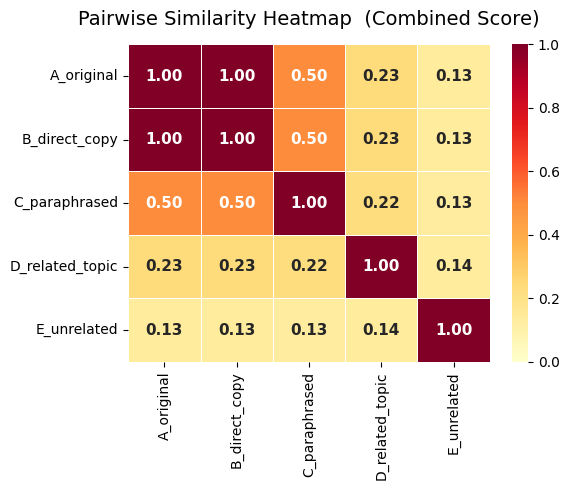

Saved → reports/score_breakdown.png


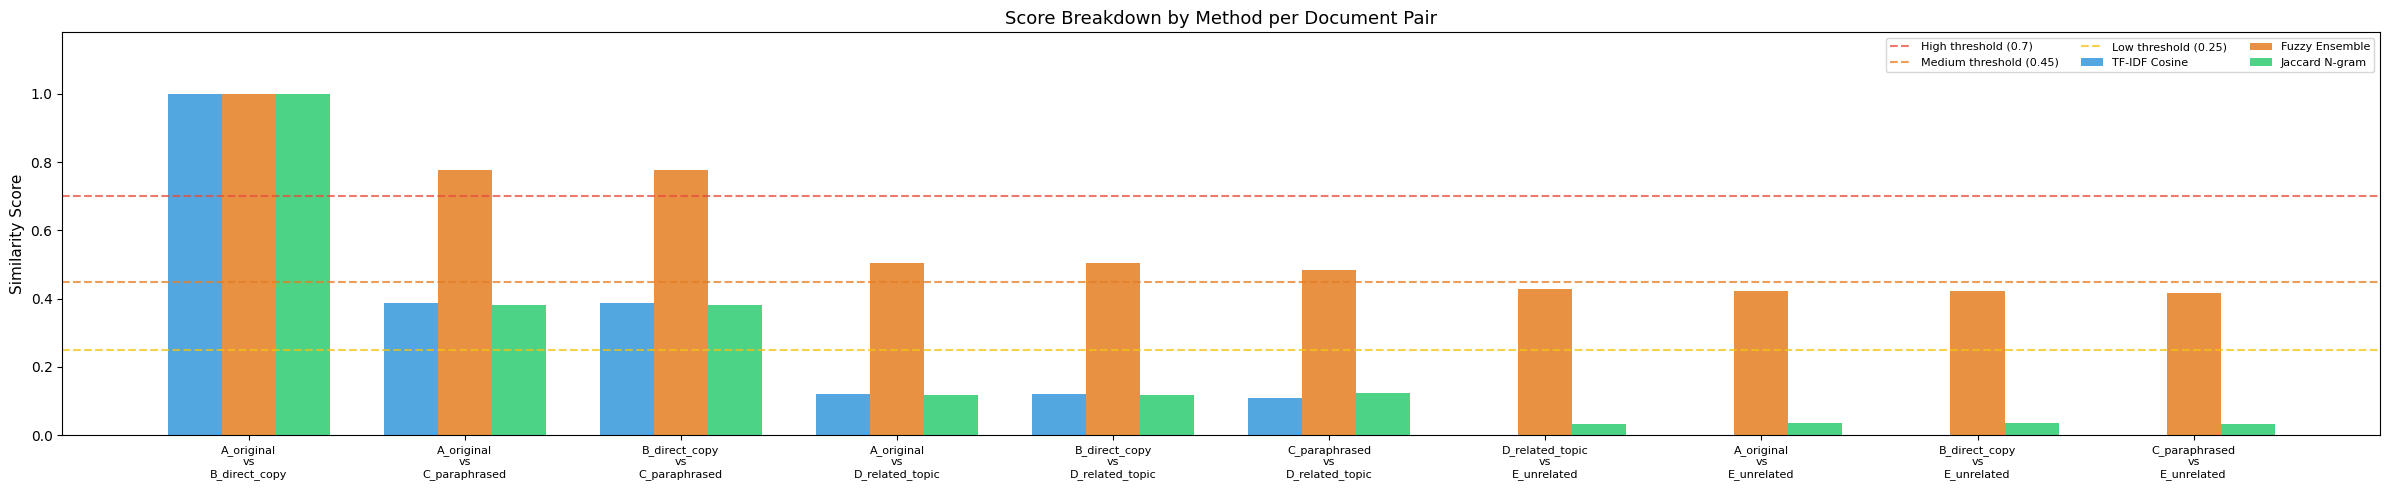

Saved → reports/severity_pie.png


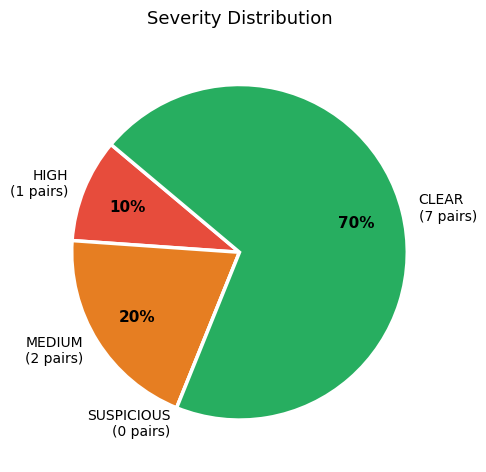

In [15]:
# ── Generate all three visualizations ─────────────────────────────────────────
plot_similarity_heatmap(checker)
plot_score_breakdown(checker)
plot_severity_pie(checker)

In [16]:
# ── Generate HTML + CSV reports ────────────────────────────────────────────────
html_path = generate_html_report(checker)
csv_df    = generate_csv_report(checker)

print(f"\n📁 All outputs saved to ./{CONFIG['report_dir']}/")
print("   ├── plagiarism_report.html")
print("   ├── results.csv")
print("   ├── similarity_heatmap.png")
print("   ├── score_breakdown.png")
print("   └── severity_pie.png")

✅ HTML report → reports/plagiarism_report.html
✅ CSV report   → reports/results.csv

📁 All outputs saved to ./reports/
   ├── plagiarism_report.html
   ├── results.csv
   ├── similarity_heatmap.png
   ├── score_breakdown.png
   └── severity_pie.png


In [17]:
def load_txt_files(folder: str) -> dict:
    """
    Load all .txt files from a directory.

    Returns
    -------
    dict : {filename: text_content}
    """
    folder = Path(folder)
    docs   = {}
    for path in sorted(folder.glob("*.txt")):
        docs[path.name] = path.read_text(encoding="utf-8", errors="ignore")
    print(f"Loaded {len(docs)} file(s) from '{folder}'")
    return docs


# Usage with your own folder:
# my_docs = load_txt_files("path/to/your/folder")
# checker = PlagiarismChecker(my_docs)
# checker.check_all()
# checker.summary()
# generate_html_report(checker, "reports/my_report.html")
# generate_csv_report(checker,  "reports/my_results.csv")


# ── Demo: run on the original starter-repo files ───────────────────────────────
starter_dir = Path("starter_docs")
starter_dir.mkdir(exist_ok=True)

starter_files = {
    "john.txt": (
        "Life is all about finding money and spending on luxury stuffs\n"
        "Coz this life is kinda short , trust"
    ),
    "juma.txt": (
        "Life to me is about finding money and use it on things that makes you happy\n"
        "coz this life is kinda short"
    ),
    "fatma.txt": (
        "Life is all about doing your best in trying to\n"
        "find what works out for you and taking most time in\n"
        "trying to pursue those skills"
    ),
}
for fname, content in starter_files.items():
    (starter_dir / fname).write_text(content)

starter_docs = load_txt_files("starter_docs")
c2 = PlagiarismChecker(starter_docs)
c2.check_all()
c2.summary()

display(
    c2.get_dataframe().style
    .background_gradient(subset=["combined_score"], cmap="YlOrRd", vmin=0, vmax=1)
    .format({c: "{:.4f}" for c in ["tfidf_score","fuzzy_score","jaccard_score","combined_score"]})
    .set_caption("Starter-repo results (john / juma / fatma)")
)

generate_html_report(c2, f"{CONFIG['report_dir']}/starter_report.html")
generate_csv_report(c2,  f"{CONFIG['report_dir']}/starter_results.csv")

Loaded 3 file(s) from 'starter_docs'

══════════════════════════════════════════════════════════
           PLAGIARISM CHECK SUMMARY
══════════════════════════════════════════════════════════
  Documents checked  : 3
  Pairs compared     : 3
──────────────────────────────────────────────────────────
  🔴 HIGH        :   0   
  🟠 MEDIUM      :   1   ████
  🟡 SUSPICIOUS  :   0   
  🟢 CLEAR       :   2   ████████
══════════════════════════════════════════════════════════



,doc_a,doc_b,tfidf_score,fuzzy_score,jaccard_score,combined_score,severity
0,john.txt,juma.txt,0.4298,0.6884,0.3486,0.4911,MEDIUM
1,fatma.txt,juma.txt,0.0339,0.5389,0.0556,0.1897,CLEAR
2,fatma.txt,john.txt,0.0339,0.5070,0.0613,0.1813,CLEAR


✅ HTML report → reports/starter_report.html
✅ CSV report   → reports/starter_results.csv


,doc_a,doc_b,tfidf_score,fuzzy_score,jaccard_score,combined_score,severity
0,john.txt,juma.txt,0.4298,0.6884,0.3486,0.4911,MEDIUM
1,fatma.txt,juma.txt,0.0339,0.5389,0.0556,0.1897,CLEAR
2,fatma.txt,john.txt,0.0339,0.5070,0.0613,0.1813,CLEAR
